<a href="https://colab.research.google.com/github/EricoCoutoJr/Projeto-de-Previs-o-de-Cancelamento-de-Reservas-Hoteleiras/blob/main/hotel_booking_demand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Recursos

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
Path to dataset files: /kaggle/input/hotel-booking-demand


In [3]:
import pandas as pd

df = pd.read_csv(path + "/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Exploração Inicial do dataset

Primeiro, vamos examinar a estrutura do DataFrame, incluindo nomes de colunas, tipos de dados e valores não nulos usando `df.info()`.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Os comandos df.info() e df.describe() foram executados.

O df.info() nos mostra que existem algumas colunas com valores ausentes:

- A coluna children tem 4 valores ausentes.
- A coluna country tem 488 valores ausentes.
- A coluna agent tem 16.340 valores ausentes.
- A coluna company tem 112.593 valores ausentes.

O df.describe() fornece estatísticas descritivas para as colunas numéricas, como média, desvio padrão, valores mínimo e máximo, e quartis. Isso nos dá uma boa visão geral da distribuição dos dados numéricos.

Concluí a exploração inicial dos dados. Analisamos as informações do DataFrame com df.info() e as estatísticas descritivas com df.describe(), **identificando colunas com valores ausentes como children, country, agent e company.**

### Porcentagem de Valores Ausentes

Vamos calcular a porcentagem de valores ausentes em cada coluna para ter uma visão mais clara da completude dos dados.

In [6]:
missing_percentage = df.isnull().sum() * 100 / len(df)
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
display(missing_percentage)

,0
company,94.306893
agent,13.686238
country,0.408744
children,0.003350


Os cálculos de porcentagem de valores ausentes foram concluídos. Podemos observar que:

- `company`: Possui uma quantidade muito alta de valores ausentes, com 94.31% dos dados faltando.
- `agent`: Também tem uma porcentagem considerável de valores ausentes, cerca de 13.69%.
- `country`: Apresenta 0.41% de valores ausentes, o que é uma quantidade relativamente pequena.
- `children`: Tem uma porcentagem muito baixa de valores ausentes, apenas 0.003%.

Com base nisso, as colunas company e agent precisarão de uma atenção especial na fase de tratamento de dados, devido à grande quantidade de informações faltantes.

### Tratamento de Valores Ausentes e Target Leakage

Agora vamos tratar os valores ausentes de acordo com a análise realizada:
1.  **Eliminar colunas**: `company` e `agent` devido ao alto número de dados ausentes.
2.  **Preencher valores nulos**: Na coluna `children` com 0 e na coluna `country` com 'Unknown'.
3. **Eliminar colunas**: `reservation_status` e `reservation_status_date` devido a Target Leakage

As colunas `reservation_status` e `reservation_status_date` são, de fato, problemáticas para a predição de cancelamento. Elas contêm informações que estão diretamente ligadas ou são uma consequência do status de cancelamento. Incluí-las como features para um modelo de predição causaria um fenômeno chamado data leakage (vazamento de dados). Isso significa que o modelo estaria 'trapaceando', usando informações do futuro para prever o passado, tornando-o artificialmente bom, mas inútil para prever cancelamentos reais antes que aconteçam.

In [7]:
# Eliminar as colunas 'company' e 'agent'
df.drop(['company', 'agent'], axis=1, inplace=True)

# Eliminar as colunas 'reservation_status' e 'reservation_status_date'
df.drop(['reservation_status', 'reservation_status_date'], axis=1, inplace=True)

# Preencher valores nulos na coluna 'children' com 0
# Preencher valores nulos na coluna 'country' com 'Unknown'
df.fillna({
    'children': 0,
    'country': 'Unknown'
}, inplace=True)

# Verificar se ainda há valores ausentes após o tratamento
missing_after_treatment = df.isnull().sum()
missing_after_treatment = missing_after_treatment[missing_after_treatment > 0]

print("Valores ausentes após o tratamento:")
display(missing_after_treatment)

Valores ausentes após o tratamento:


,0


### Verificação de Registros Duplicados

Vamos identificar e contar os registros duplicados no DataFrame `df` para entender se existem entradas idênticas que precisam ser tratadas.

In [8]:
num_duplicates = df.duplicated().sum()
print(f"Número de registros duplicados: {num_duplicates}")

Número de registros duplicados: 32280


A verificação de registros duplicados foi concluída! Encontramos **32.280 registros duplicados** no DataFrame.

### Visualizando os Registros Duplicados

A seguir, apresentamos uma amostra dos registros que foram identificados como duplicados. Isso permitirá uma análise mais detalhada antes de qualquer ação de remoção.

In [9]:
duplicated_rows = df[df.duplicated(keep=False)]
display(duplicated_rows.sort_values(by=list(df.columns)).head(10))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
40772,City Hotel,0,0,2015,August,32,7,0,2,2,...,0,A,A,0,No Deposit,0,Transient,75.0,0,1
40802,City Hotel,0,0,2015,August,32,7,0,2,2,...,0,A,A,0,No Deposit,0,Transient,75.0,0,1
40821,City Hotel,0,0,2015,August,32,8,0,1,2,...,0,A,A,0,No Deposit,0,Transient,89.0,0,1
40838,City Hotel,0,0,2015,August,32,8,0,1,2,...,0,A,A,0,No Deposit,0,Transient,89.0,0,1
76792,City Hotel,0,0,2015,August,33,10,1,0,2,...,0,A,A,0,No Deposit,0,Transient,75.0,0,0
76793,City Hotel,0,0,2015,August,33,10,1,0,2,...,0,A,A,0,No Deposit,0,Transient,75.0,0,0
76794,City Hotel,0,0,2015,August,33,10,1,0,2,...,0,A,A,0,No Deposit,0,Transient,75.0,0,0
41067,City Hotel,0,0,2015,August,33,11,0,1,1,...,0,A,A,0,No Deposit,0,Transient-Party,88.0,0,0
41073,City Hotel,0,0,2015,August,33,11,0,1,1,...,0,A,A,0,No Deposit,0,Transient-Party,88.0,0,0
41071,City Hotel,0,0,2015,August,33,11,0,1,2,...,0,A,A,0,No Deposit,0,Transient,80.0,0,0


### Análise das Características dos Registros Duplicados

Vamos examinar a distribuição de algumas colunas categóricas importantes nos registros identificados como duplicados. Isso nos ajudará a entender se existem padrões ou características comuns entre essas entradas repetidas.

In [10]:
print("Distribuição de Hotéis nos Registros Duplicados:")
display(duplicated_rows['hotel'].value_counts())

print("\nDistribuição de Segmentos de Mercado nos Registros Duplicados:")
display(duplicated_rows['market_segment'].value_counts())

print("\nDistribuição de Tipos de Clientes nos Registros Duplicados:")
display(duplicated_rows['customer_type'].value_counts())

print("Distribuição completa de Tipos de Clientes nos Registros Duplicados:")
display(duplicated_rows['customer_type'].value_counts())

Distribuição de Hotéis nos Registros Duplicados:


,count
hotel,
City Hotel,31957
Resort Hotel,8537



Distribuição de Segmentos de Mercado nos Registros Duplicados:


,count
market_segment,
Groups,16763
Offline TA/TO,12254
Online TA,8462
Corporate,1496
Direct,1425
Complementary,75
Aviation,19



Distribuição de Tipos de Clientes nos Registros Duplicados:


,count
customer_type,
Transient,22422
Transient-Party,16825
Contract,1190
Group,57


Distribuição completa de Tipos de Clientes nos Registros Duplicados:


,count
customer_type,
Transient,22422
Transient-Party,16825
Contract,1190
Group,57


Como as duplicatas podem afetar o modelo:

1.**Overfitting (Superajuste)**: O modelo pode aprender a prever o ruído ou os padrões específicos dessas observações repetidas em vez de aprender as relações subjacentes nos dados. Isso faz com que ele performe muito bem nos dados de treinamento (que contêm as duplicatas), mas generalize mal para novos dados.

2.**Métricas de Avaliação Enviesadas:** As métricas de avaliação (como acurácia, precisão, recall) calculadas em um conjunto de dados com duplicatas podem ser artificialmente infladas, dando a impressão de um desempenho melhor do que o real.

3.**Representação Incorreta da Distribuição:** As duplicatas podem distorcer a distribuição real das classes, especialmente se uma classe específica (como 'is_canceled' = 1) for mais representada nas duplicatas. Isso pode levar o modelo a ter um viés em favor dessa classe.

Em resumo, para garantir que o modelo aprenda com a verdadeira diversidade dos dados e que suas avaliações sejam mais precisas, é uma boa prática remover esses registros duplicados.

### Análise da Variável 'is_canceled' em Registros Duplicados e Únicos

Vamos verificar a proporção de cancelamentos (`is_canceled` = 1) e não cancelamentos (`is_canceled` = 0) em dois grupos:
1.  **Registros Duplicados**: Para entender o comportamento de cancelamento nessas entradas repetidas.
2.  **Registros Únicos**: Para comparar com os registros duplicados e ter uma visão mais clara da distribuição real da variável target.

In [11]:
# Criar um DataFrame com registros únicos
unique_rows = df.drop_duplicates(keep='first')

# Calcular a porcentagem de 'is_canceled' para registros duplicados
print("Porcentagem de 'is_canceled' nos registros duplicados:")
display(duplicated_rows['is_canceled'].value_counts(normalize=True) * 100)

# Calcular a porcentagem de 'is_canceled' para registros únicos
print("\nPorcentagem de 'is_canceled' nos registros únicos:")
display(unique_rows['is_canceled'].value_counts(normalize=True) * 100)

Porcentagem de 'is_canceled' nos registros duplicados:


,proportion
is_canceled,
1,58.638317
0,41.361683



Porcentagem de 'is_canceled' nos registros únicos:


,proportion
is_canceled,
0,72.722994
1,27.277006


Os resultados revelam uma diferença significativa na distribuição da variável is_canceled entre os registros duplicados e únicos:

**Registros Duplicados:**

- **58.64%** são cancelados (is_canceled = 1)
- **41.36%** não são cancelados (is_canceled = 0)

**Registros Únicos:**

- **27.28%** são cancelados (is_canceled = 1)
- **72.72%** não são cancelados (is_canceled = 0)

Essa análise reforça a ideia de que os registros duplicados não apenas inflacionam o volume de dados, mas também podem distorcer a percepção da taxa de cancelamento, apresentando uma proporção muito maior de cancelamentos em comparação com os registros únicos. Isso confirma o risco de viés e overfitting que as duplicatas podem introduzir em um modelo preditivo.

### Remoção de Registros Duplicados

Com base na análise anterior, onde identificamos **32.280 registros duplicados** e observamos seu impacto potencial na distorção da variável `is_canceled`, vamos agora remover esses registros do DataFrame `df`.

In [12]:
df.drop_duplicates(inplace=True)

# Verificar o número de registros após a remoção de duplicados
print(f"Número de registros após a remoção de duplicados: {df.shape[0]}")

# Verificar se ainda há duplicados
num_duplicates_after_removal = df.duplicated().sum()
print(f"Número de registros duplicados após a remoção: {num_duplicates_after_removal}")

Número de registros após a remoção de duplicados: 87110
Número de registros duplicados após a remoção: 0


Os registros duplicados foram removidos com sucesso do DataFrame. Agora temos 87.110 registros únicos no conjunto de dados, e a verificação confirmou que não há mais duplicatas.

### Verificação e Conversão de Tipos de Dados

Agora que os valores ausentes e os registros duplicados foram tratados, vamos analisar os tipos de dados (`dtypes`) das colunas. A conversão de colunas categóricas para o tipo `category` do pandas e a otimização de tipos numéricos pode reduzir o uso de memória e melhorar a performance do modelo.

In [13]:
# Exibir as informações do DataFrame para verificar os tipos de dados atuais
print("Informações do DataFrame antes da conversão de tipos:")
df.info()

Informações do DataFrame antes da conversão de tipos:
<class 'pandas.core.frame.DataFrame'>
Index: 87110 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87110 non-null  object 
 1   is_canceled                     87110 non-null  int64  
 2   lead_time                       87110 non-null  int64  
 3   arrival_date_year               87110 non-null  int64  
 4   arrival_date_month              87110 non-null  object 
 5   arrival_date_week_number        87110 non-null  int64  
 6   arrival_date_day_of_month       87110 non-null  int64  
 7   stays_in_weekend_nights         87110 non-null  int64  
 8   stays_in_week_nights            87110 non-null  int64  
 9   adults                          87110 non-null  int64  
 10  children                        87110 non-null  float64
 11  babies                          87110 non-n

### Conversão de Colunas Categóricas e Numéricas

Com base na análise do `df.info()`, vamos converter as colunas `object` que representam categorias para o tipo `category`. Além disso, a coluna `children`, que é um float, será convertida para `int`.

Esta otimização reduzirá a pegada de memória do DataFrame e pode acelerar as operações subsequentes, especialmente aquelas envolvidas na preparação e treinamento de modelos.

In [14]:
# Converter colunas 'object' para 'category'
categorical_cols = [
    'hotel',
    'arrival_date_month',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'customer_type'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

# Converter 'children' de float para int, pois representa uma contagem
df['children'] = df['children'].astype(int)

print("Tipos de dados após a conversão:")
df.info()

Tipos de dados após a conversão:
<class 'pandas.core.frame.DataFrame'>
Index: 87110 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           87110 non-null  category
 1   is_canceled                     87110 non-null  int64   
 2   lead_time                       87110 non-null  int64   
 3   arrival_date_year               87110 non-null  int64   
 4   arrival_date_month              87110 non-null  category
 5   arrival_date_week_number        87110 non-null  int64   
 6   arrival_date_day_of_month       87110 non-null  int64   
 7   stays_in_weekend_nights         87110 non-null  int64   
 8   stays_in_week_nights            87110 non-null  int64   
 9   adults                          87110 non-null  int64   
 10  children                        87110 non-null  int64   
 11  babies                          87110 non-null  int

Agora temos 10 colunas do tipo category, 17 do tipo int64 e 1 do tipo float64.

Observe que a memory usage (uso de memória) do DataFrame foi reduzida para **13.5 MB**, uma otimização significativa em comparação com os **19.3+ MB** anteriores. Isso contribuirá para uma maior eficiência na criação do modelo.

### Criação da Feature `total_nights`

Como discutido, a variável `total_nights` (noites totais de estadia) é uma feature de engenharia que pode ser muito relevante para o modelo. Ela será criada somando as colunas `stays_in_weekend_nights` e `stays_in_week_nights`.

**Por que total_nights é útil:**

1.**Representação mais direta:** Em vez de o modelo tentar inferir a duração total da estadia a partir de duas variáveis separadas, você está fornecendo essa informação diretamente. Isso pode simplificar o processo de aprendizado do modelo.

2.**Relação com o comportamento de reserva:** A duração total da estadia é um fator crucial no comportamento de reserva e cancelamento. Estadias mais curtas ou mais longas podem ter diferentes taxas de cancelamento ou serem impactadas de maneiras distintas por outras variáveis (como preço, tipo de cliente, etc.).

3.**Redução de dimensionalidade (implícita):** Embora não seja uma redução direta, ela condensa duas variáveis relacionadas em uma única feature mais significativa, o que pode ajudar o modelo a capturar padrões de forma mais eficiente.

Vamos em frente e criaremos esta nova coluna total_nights no DataFrame.

In [15]:
# Criar a coluna 'total_nights'
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

print("Coluna 'total_nights' criada com sucesso.")

# Exibir as primeiras linhas com a nova coluna
display(df[['stays_in_weekend_nights', 'stays_in_week_nights', 'total_nights']].head())

Coluna 'total_nights' criada com sucesso.


,stays_in_weekend_nights,stays_in_week_nights,total_nights
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


A coluna total_nights foi criada com sucesso e já está disponível no seu DataFrame, conforme visualizado nas primeiras linhas. Esta nova feature está pronta para ser utilizada na próxima fase de análise ou na construção do modelo.

### Padronização dos Nomes das Colunas

Para facilitar a manipulação e a leitura do DataFrame, vamos padronizar os nomes das colunas, convertendo-os para o formato `snake_case` (minúsculas com sublinhados).

Essa prática melhora a consistência e evita problemas futuros com o acesso às colunas.

In [16]:
# Padronizar os nomes das colunas para snake_case
def standardize_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.replace(' ', '_').lower()
        new_cols.append(new_col)
    df.columns = new_cols
    return df

df = standardize_col_names(df)

print("Nomes das colunas após padronização:")
display(df.columns)

Nomes das colunas após padronização:


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_nights'],
      dtype='object')

### Identificação e Tratamento de Outliers

Outliers, ou valores atípicos, são pontos de dados que se desviam significativamente de outras observações. Eles podem ser causados por erros de medição, erros de entrada de dados ou podem ser variações verdadeiras no processo. A presença de outliers pode distorcer a análise estatística e afetar negativamente o desempenho de modelos de Machine Learning.

Nesta fase, vamos:
1.  **Identificar** os outliers em algumas das colunas numéricas mais relevantes.
2.  **Discutir** as estratégias para tratá-los, se necessário.

Começaremos visualizando as estatísticas descritivas para ter uma primeira ideia de possíveis outliers.

In [17]:
# Visualizar as estatísticas descritivas para as colunas numéricas
print("Estatísticas Descritivas para Colunas Numéricas (com foco em min/max):")
display(df.describe().T)

Estatísticas Descritivas para Colunas Numéricas (com foco em min/max):


,count,mean,std,min,25%,50%,75%,max
is_canceled,87110.0,0.272770,0.445386,0.00,0.0,0.0,1.0,1.0
lead_time,87110.0,79.727563,85.944230,0.00,11.0,49.0,125.0,737.0
arrival_date_year,87110.0,2016.210527,0.685975,2015.00,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,87110.0,26.836666,13.674381,1.00,16.0,27.0,37.0,53.0
arrival_date_day_of_month,87110.0,15.815038,8.835223,1.00,8.0,16.0,23.0,31.0
stays_in_weekend_nights,87110.0,1.005418,1.031590,0.00,0.0,1.0,2.0,19.0
stays_in_week_nights,87110.0,2.625577,2.051753,0.00,1.0,2.0,4.0,50.0
adults,87110.0,1.875927,0.626816,0.00,2.0,2.0,2.0,55.0
children,87110.0,0.138893,0.456270,0.00,0.0,0.0,0.0,10.0
babies,87110.0,0.010837,0.113682,0.00,0.0,0.0,0.0,10.0


As estatísticas descritivas fornecem uma boa visão geral inicial das nossas colunas numéricas. Ao revisar os valores min e max, identifiquei algumas colunas que se destacam com potenciais outliers:

- **adr (Taxa Diária Média):**

  - O valor mínimo é -6.38, o que é ilógico para uma taxa diária e indica um erro ou anomalia na entrada de dados.
  - O valor máximo é 5400.0, o que é extremamente alto em comparação com o 75º percentil de 134.0, sugerindo fortemente um outlier.
- **adults (Adultos):** O valor máximo é 55, o que parece excepcionalmente alto para uma única reserva de hotel e provavelmente é um outlier.
- **babies (Bebês):** O valor máximo é 10, o que é incomumente alto e pode ser um outlier.
- **total_nights (Noites Totais):** O valor máximo é 69, indicando uma estadia muito longa, o que poderia ser um outlier dependendo do contexto.
- Outras colunas como lead_time, `stays_in_week_nights`, `previous_cancellations`, `previous_bookings_not_canceled`, `booking_changes` e `days_in_waiting_list` também mostram valores máximos elevados, mas adr, adults e babies são os mais imediatamente preocupantes devido aos seus valores implausíveis.

Em seguida, devemos investigar esses potenciais outliers mais a fundo, talvez usando visualizações como box plots, para confirmar sua presença e distribuição antes de decidir sobre uma estratégia de tratamento.

### Visualização de Outliers com Boxplots

Para confirmar visualmente a presença e a extensão dos outliers, vamos criar boxplots para as colunas identificadas:

*   `adr` (Average Daily Rate)
*   `adults` (Adultos)
*   `babies` (Bebês)
*   `total_nights` (Noites Totais)

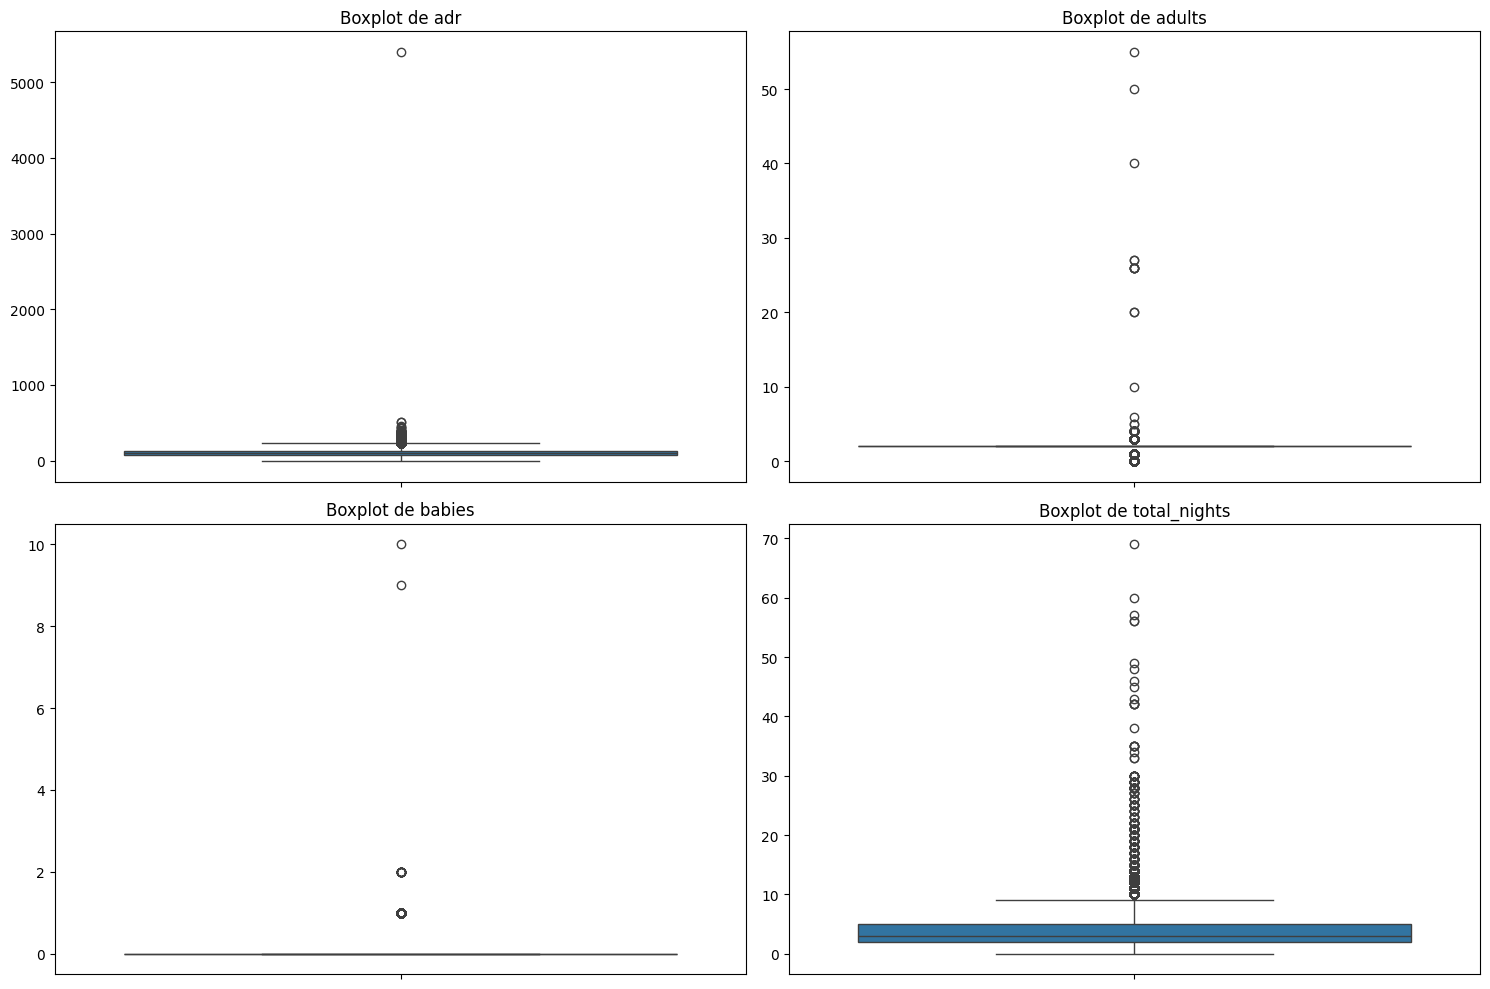

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de colunas para visualizar outliers
columns_to_plot = ['adr', 'adults', 'babies', 'total_nights']

plt.figure(figsize=(15, 10))
for i, col in enumerate(columns_to_plot):
    plt.subplot(2, 2, i + 1)  # 2 linhas, 2 colunas de subplots
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel('') # Remover rótulo do eixo y para evitar sobreposição
plt.tight_layout()
plt.show()

### Tratamento de Outliers

Com base na análise dos boxplots e das estatísticas descritivas, vamos prosseguir com o tratamento dos outliers. Começaremos com as inconsistências mais óbvias:

1.  **Remover registros com 0 hóspedes:** Reservas com 0 adultos, 0 crianças e 0 bebês são ilógicas e serão removidas.
2.  **Tratar valores negativos de `adr`:** Valores negativos na taxa diária média (`adr`) são erros e serão removidos.

**Estratégias de Tratamento Propostas:**

1.**`adr` (Average Daily Rate):**
  - **Valores negativos:** O valor de -6.38 para adr é fisicamente impossível. Propõe-se remover ou substituir esses registros por um valor apropriado (como a mediana ou 0, dependendo da interpretação do que significa um adr negativo). Por ser um erro claro, a remoção é uma opção forte ou a substituição por 0 se significar 'grátis'.

  - **Valores muito altos:** Os valores extremos (como 5400) podem ser limitados (capping) em um percentil alto (e.g., 99º percentil) para evitar que distorçam o modelo, ou removidos se forem considerados erros. Para começar, considerarei limitar esses valores.

**`adults`, `children`, `babies`**:

  - Registros com adults + children + babies igual a 0 não fazem sentido para uma reserva de hotel (uma vez que não teria hóspedes). Estes registros devem ser removidos.
  - Valores muito altos para adults (como 55) e babies (como 10) são provavelmente erros. Propõe-se limitar esses valores ou removê-los se forem muito poucos e claramente errados. Uma abordagem é redefinir o número máximo razoável de hóspedes (e.g., 4 adultos, 2 crianças, 2 bebês por quarto ou um limite total razoável para o número total de pessoas).
Vamos começar tratando o caso dos hóspedes zero e então os valores negativos de ADR, seguidos pelos valores extremos de ADR e hóspedes.

In [19]:
# Remover registros com 0 hóspedes (adults + children + babies == 0)
initial_rows = df.shape[0]
df = df[df['adults'] + df['children'] + df['babies'] > 0]
removed_rows_guests = initial_rows - df.shape[0]
print(f"Removidos {removed_rows_guests} registros com 0 hóspedes.")

# Remover registros com 'adr' negativo
initial_rows = df.shape[0]
df = df[df['adr'] >= 0]
removed_rows_adr_neg = initial_rows - df.shape[0]
print(f"Removidos {removed_rows_adr_neg} registros com ADR negativo.")

print(f"Número de registros após o tratamento inicial de outliers: {df.shape[0]}")

Removidos 166 registros com 0 hóspedes.
Removidos 1 registros com ADR negativo.
Número de registros após o tratamento inicial de outliers: 86943


### Tratamento de Outliers - Valores Extremos (Capping e Remoção)

Após o tratamento inicial, vamos agora focar nos outliers extremos restantes, aplicando as seguintes estratégias:

1.  **Capping para `adr`**: Os valores de `adr` muito elevados serão limitados ao percentil 99.5 para mitigar seu impacto sem remover um grande volume de dados.
2.  **Remoção de valores implausíveis para `adults` e `babies`**: Registros com 55 adultos e 10 bebês são considerados erros de dados e serão removidos.

Agora, vamos continuar o tratamento dos outliers para os valores extremos de adr, adults e babies:

- **`adr`:** Vou limitar os valores de adr ao percentil 99.5. Isso significa que qualquer valor acima desse limite será substituído pelo valor do percentil 99.5, controlando os picos sem remover muitos dados.
- **`adults`**: O valor de 55 adultos é claramente um erro de entrada de dados. Vou remover esses registros específicos, pois são implausíveis para uma única reserva.
- **`babies`**: De forma semelhante, 10 bebês em uma única reserva é um valor irreal. Vou remover esses registros também.

Esta abordagem nos ajudará a ter um conjunto de dados mais limpo e realista para o treinamento do modelo.

In [20]:
# 1. Capping para 'adr' (taxa diária média) em valores muito altos
adr_upper_bound = df['adr'].quantile(0.995)
df.loc[df['adr'] > adr_upper_bound, 'adr'] = adr_upper_bound
print(f"Valores de 'adr' acima de {adr_upper_bound:.2f} foram limitados.")

# 2. Remover registros com 'adults' muito alto (e.g., 55) ou 'babies' muito alto (e.g., 10)
initial_rows = df.shape[0]

# Remover adultos implausíveis (e.g. 55)
df = df[df['adults'] <= 4] # Assumindo um máximo razoável de 4 adultos por reserva

# Remover bebês implausíveis (e.g. 10)
df = df[df['babies'] <= 2] # Assumindo um máximo razoável de 2 bebês por reserva

removed_rows_extreme_guests = initial_rows - df.shape[0]
print(f"Removidos {removed_rows_extreme_guests} registros com números extremos de adultos/bebês.")

print(f"Número final de registros após todo o tratamento de outliers: {df.shape[0]}")

# Verificar novamente as estatísticas descritivas para ver o efeito
print("Estatísticas Descritivas para Colunas Numéricas após tratamento de outliers:")
display(df.describe().T)

Valores de 'adr' acima de 285.00 foram limitados.
Removidos 18 registros com números extremos de adultos/bebês.
Número final de registros após todo o tratamento de outliers: 86925
Estatísticas Descritivas para Colunas Numéricas após tratamento de outliers:


,count,mean,std,min,25%,50%,75%,max
is_canceled,86925.0,0.272982,0.445494,0.0,0.00,0.00,1.0,1.0
lead_time,86925.0,79.759689,85.887304,0.0,11.00,49.00,125.0,737.0
arrival_date_year,86925.0,2016.210814,0.685797,2015.0,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,86925.0,26.831383,13.668947,1.0,16.00,27.00,37.0,53.0
arrival_date_day_of_month,86925.0,15.816416,8.835695,1.0,8.00,16.00,23.0,31.0
stays_in_weekend_nights,86925.0,1.004602,1.027039,0.0,0.00,1.00,2.0,19.0
stays_in_week_nights,86925.0,2.623814,2.037923,0.0,1.00,2.00,4.0,50.0
adults,86925.0,1.875318,0.504418,0.0,2.00,2.00,2.0,4.0
children,86925.0,0.139189,0.456710,0.0,0.00,0.00,0.0,10.0
babies,86925.0,0.010641,0.104275,0.0,0.00,0.00,0.0,2.0


O tratamento de outliers foi concluído com sucesso. Observamos as seguintes mudanças nas estatísticas descritivas:

- **`adr`**: O valor máximo de adr agora está limitado a **285.00**, o que significa que os valores extremamente altos foram ajustados, tornando a distribuição mais robusta. O valor mínimo permanece em 0.0, confirmando que os negativos foram removidos.
- **`adults`**: O número máximo de adultos foi limitado a **4**, eliminando o valor implausível de 55. Isso garante que os dados representem cenários mais realistas de reservas de hotel.
- **`babies`**: O número máximo de bebês agora é **2**, removendo os registros com 10 bebês que eram claramente erros de dados.
- No total, **18** registros com números extremos de adultos/bebês foram removidos, resultando em **86.925** registros finais após todo o tratamento de outliers.
Com a limpeza dos outliers concluída, o nosso DataFrame está mais consistente e pronto para a próxima fase. O próximo passo fundamental será a **codificação das variáveis categóricas**.

### Codificação de Variáveis Categóricas

Com o tratamento de outliers finalizado, o próximo passo crucial na preparação dos dados é converter as variáveis categóricas em um formato numérico que possa ser utilizado pelos modelos de Machine Learning.

**Por que codificar variáveis categóricas?**
*   **Compatibilidade do Modelo:** A maioria dos algoritmos de ML opera com entradas numéricas.
*   **Representação Eficaz:** A codificação permite que o modelo interprete as categorias e suas relações.

Vamos identificar as colunas categóricas restantes e aplicar uma estratégia de codificação adequada, como One-Hot Encoding ou Label Encoding, dependendo da natureza da variável.

In [21]:
# Identificar colunas categóricas que ainda não são numéricas (excluindo 'is_canceled' que é o target)
categorical_cols = df.select_dtypes(include='category').columns.tolist()
print("Colunas categóricas identificadas para codificação:")
print(categorical_cols)

# Aplicar One-Hot Encoding para as colunas categóricas
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape do DataFrame após One-Hot Encoding:", df_encoded.shape)
print("Primeiras 5 linhas do DataFrame codificado:")
display(df_encoded.head())

Colunas categóricas identificadas para codificação:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Shape do DataFrame após One-Hot Encoding: (86925, 248)
Primeiras 5 linhas do DataFrame codificado:


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,2015,27,1,0,0,2,0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,737,2015,27,1,0,0,2,0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,7,2015,27,1,0,1,1,0,0,...,False,False,False,False,False,False,False,False,True,False
3,0,13,2015,27,1,0,1,1,0,0,...,False,False,False,False,False,False,False,False,True,False
4,0,14,2015,27,1,0,2,2,0,0,...,False,False,False,False,False,False,False,False,True,False


A codificação One-Hot foi aplicada com sucesso às colunas categóricas. Como você pode ver, nosso DataFrame agora tem 248 colunas, o que é esperado após a criação de novas colunas para cada categoria. O cabeçalho mostra as novas colunas booleanas resultantes da codificação.

Com os dados agora totalmente numéricos, estamos prontos para a próxima etapa essencial na preparação do modelo: **dividir o conjunto de dados em features (X) e o alvo (y), e depois em conjuntos de treinamento e teste**. Isso é crucial para treinar nosso modelo de forma eficaz e avaliar seu desempenho em dados não

### Divisão dos Dados em Conjuntos de Treinamento e Teste

Agora que todas as variáveis categóricas foram codificadas e os dados estão limpos, vamos dividir o DataFrame em:

1.  **Features (X)**: As colunas que serão usadas como entrada para o modelo.
2.  **Target (y)**: A variável que o modelo tentará prever (`is_canceled`).

Em seguida, dividiremos X e y em conjuntos de treinamento e teste (`X_train`, `X_test`, `y_train`, `y_test`). Esta divisão é fundamental para avaliar o desempenho do modelo em dados que ele não viu durante o treinamento, garantindo uma avaliação realista de sua capacidade de generalização.

In [22]:
from sklearn.model_selection import train_test_split

# Separar features (X) e target (y)
X = df_encoded.drop('is_canceled', axis=1)
y = df_encoded['is_canceled']

# Dividir os dados em conjuntos de treinamento e teste
# Usaremos uma proporção de 80% para treinamento e 20% para teste
# random_state para reprodutibilidade

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

print("\nDistribuição da classe 'is_canceled' no conjunto de treinamento:")
display(y_train.value_counts(normalize=True))

print("\nDistribuição da classe 'is_canceled' no conjunto de teste:")
display(y_test.value_counts(normalize=True))

Shape de X_train: (69540, 247)
Shape de X_test: (17385, 247)
Shape de y_train: (69540,)
Shape de y_test: (17385,)

Distribuição da classe 'is_canceled' no conjunto de treinamento:


,proportion
is_canceled,
0,0.72702
1,0.27298



Distribuição da classe 'is_canceled' no conjunto de teste:


,proportion
is_canceled,
0,0.727006
1,0.272994


 Os dados foram divididos com sucesso em conjuntos de treinamento e teste. As distribuições da variável `is_canceled` em ambos os conjuntos estão muito próximas (aproximadamente 72.7% de não cancelados e 27.3% de cancelados), o que indica que a estratificação funcionou perfeitamente e os conjuntos são representativos.

Agora que os dados estão separados e prontos para o treinamento, o próximo passo crucial é a **Escala de Features**. Algoritmos de Machine Learning, especialmente aqueles baseados em distância (como KNN e SVMs) ou gradientes (como Regressão Logística e Redes Neurais), podem ter seu desempenho afetado por features que possuem diferentes escalas. A escala garante que todas as features contribuam igualmente para o modelo, evitando que features com valores maiores dominem o processo de aprendizado.

### Escala de Features (Feature Scaling)

A escala de features é uma etapa de pré-processamento essencial em Machine Learning, onde os valores das features numéricas são transformados para uma escala comum, sem distorcer as diferenças nas faixas de valores.

**Por que realizar a escala de features?**

1.  **Melhora o desempenho de algoritmos**: Muitos algoritmos de ML (e.g., SVMs, Regressão Logística, Redes Neurais, KNN) convergem mais rapidamente e performam melhor quando as features estão na mesma escala.
2.  **Evita o domínio de features**: Features com grandes ranges de valores não dominarão indevidamente a função de custo.
3.  **Melhora a interpretabilidade**: Em alguns casos, pode facilitar a interpretação dos coeficientes do modelo.

Usaremos o `StandardScaler`, que padroniza as features removendo a média e escalando para a variância unitária (tornando a média 0 e o desvio padrão 1).

In [23]:
from sklearn.preprocessing import StandardScaler

# Identificar colunas numéricas para escalar (excluindo as que já são 0/1 ou booleanas do one-hot encoding)
# Features geradas pelo One-Hot Encoding são tipicamente booleanas e não necessitam de escalagem com StandardScaler

# Selecionar apenas as colunas numéricas originais e as que ainda têm range significativo
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Excluir colunas que são essencialmente binárias ou já estão em uma escala pequena/normalizada,
# como 'is_repeated_guest' ou as colunas do one-hot encoding que são True/False.
# Uma forma de fazer isso é filtrar as colunas onde o número de valores únicos é muito baixo (ex: <= 2)
# ou aquelas que sabemos que são resultantes do one-hot encoding.

# Para simplicidade e eficácia, vamos escalar todas as colunas que não são resultado do one-hot encoding
# e que não são a target 'is_canceled'.

# Vamos garantir que não escalamos as colunas resultantes do One-Hot Encoding (que são binárias 0/1) para não distorcer sua natureza
# E também não escalar a 'is_canceled' (que é a target)

# Selecionar colunas numéricas a serem escaladas
# Todas as colunas numéricas que não são binárias (resultantes do one-hot encoding) e não são a target

# Obter as colunas que eram categóricas e foram convertidas para one-hot encoding
original_categorical_cols = df.select_dtypes(include='category').columns.tolist()
one_hot_encoded_cols = [col for col in X.columns if any(cat_col in col for cat_col in original_categorical_cols)]

# Colunas numéricas que realmente precisam de scaling (não são binárias ou one-hot encoded)
# Para este dataset, a maioria das colunas numéricas 'int64' ou 'float64' originais se beneficiarão da escala
# Exceto 'is_canceled' que já foi removida para X

# Identificar as colunas que *não* são one-hot encoded (e, portanto, são as originais numéricas)
columns_to_scale = [col for col in X_train.columns if col not in one_hot_encoded_cols and X_train[col].nunique() > 2]


# Inicializar o StandardScaler
scaler = StandardScaler()

# Aplicar o StandardScaler aos dados de treinamento e teste
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

print("Features escaladas com sucesso!")
print("Primeiras 5 linhas de X_train_scaled (após escala):")
display(X_train_scaled.head())
print("Primeiras 5 linhas de X_test_scaled (após escala):")
display(X_test_scaled.head())

Features escaladas com sucesso!
Primeiras 5 linhas de X_train_scaled (após escala):


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
8455,-0.287606,-0.307756,0.961763,1.602427,-0.978491,-0.306405,0.246619,4.080758,-0.102894,0,...,False,False,False,False,False,False,False,False,True,False
8694,2.997289,-0.307756,1.107941,-0.772692,0.969332,1.165068,0.246619,-0.303439,-0.102894,0,...,False,False,False,False,False,False,False,False,False,True
26035,0.993736,-0.307756,-0.061487,0.584519,6.812802,8.522432,0.246619,-0.303439,-0.102894,0,...,False,False,False,False,False,False,False,False,True,False
18165,-0.776846,-1.767006,1.327209,-1.677499,1.943244,1.165068,0.246619,-0.303439,-0.102894,0,...,False,False,False,False,False,False,False,False,True,False
53820,0.714170,-0.307756,0.011602,1.602427,-0.978491,0.184086,0.246619,-0.303439,-0.102894,0,...,False,False,False,False,False,False,False,False,True,False


Primeiras 5 linhas de X_test_scaled (após escala):


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
36883,1.436381,1.151494,-0.426933,1.036923,0.969332,1.165068,0.246619,4.080758,-0.102894,0,...,False,False,False,False,False,False,False,False,False,True
48158,-0.637063,-0.307756,-1.084736,0.245216,-0.978491,-0.796896,0.246619,-0.303439,-0.102894,0,...,False,False,False,False,False,False,False,False,True,False
53687,0.038553,-0.307756,0.011602,1.263124,-0.004580,0.184086,-1.734425,-0.303439,-0.102894,0,...,False,False,False,False,False,False,False,False,True,False
63519,-0.089581,1.151494,-1.450182,-0.320288,-0.004580,-1.287387,0.246619,-0.303439,-0.102894,0,...,False,False,False,False,False,False,False,False,True,False
114578,-0.578821,1.151494,-0.134576,0.584519,-0.978491,0.184086,0.246619,-0.303439,-0.102894,0,...,False,False,False,False,False,False,False,False,True,False


As features numéricas foram escaladas com sucesso usando StandardScaler e os dataframes `X_train_scaled` e `X_test_scaled` foram criados. Isso conclui a fase de pré-processamento dos dados, deixando-os prontos para o treinamento do modelo.

### Escolha e Treinamento do Modelo de Machine Learning: Regressão Logística

Agora que os dados estão pré-processados e escalados, estamos prontos para escolher e treinar nosso modelo de Machine Learning. Para este problema de classificação binária (cancelado ou não cancelado), a **Regressão Logística** é uma excelente escolha para começar. É um algoritmo linear, eficiente e oferece boa interpretabilidade.

**Passos:**
1.  **Importar** a Regressão Logística do scikit-learn.
2.  **Instanciar** o modelo.
3.  **Treinar** o modelo (`fit`) com `X_train_scaled` e `y_train`.
4.  **Fazer previsões** (`predict`) em `X_test_scaled`.

In [24]:
from sklearn.linear_model import LogisticRegression

# Inicializar o modelo de Regressão Logística
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' é bom para datasets pequenos e para L1/L2 regularization

# Treinar o modelo com os dados de treinamento escalados
log_reg_model.fit(X_train_scaled, y_train)

print("Modelo de Regressão Logística treinado com sucesso!")

# Fazer previsões no conjunto de teste escalado
y_pred = log_reg_model.predict(X_test_scaled)
y_pred_proba = log_reg_model.predict_proba(X_test_scaled)[:, 1] # Probabilidades da classe positiva (cancelado)

print("Previsões realizadas no conjunto de teste.")

Modelo de Regressão Logística treinado com sucesso!
Previsões realizadas no conjunto de teste.


O modelo de Regressão Logística foi treinado com sucesso. Agora, vamos avaliar o desempenho do modelo no conjunto de testes para entender o quão bem ele está prevendo os cancelamentos. Vamos usar métricas como acurácia, precisão, recall, F1-score e a matriz de confusão.

### Avaliação do Modelo de Regressão Logística

Com as previsões `y_pred` e `y_pred_proba` disponíveis, podemos agora avaliar o desempenho do nosso modelo de Regressão Logística. Utilizaremos métricas de classificação padrão para entender a eficácia do modelo:

*   **Acurácia**: Proporção de previsões corretas sobre o total de previsões.
*   **Precisão**: Proporção de verdadeiros positivos em relação a todos os resultados positivos previstos. Relevante quando o custo de um falso positivo é alto.
*   **Recall (Sensibilidade)**: Proporção de verdadeiros positivos em relação a todos os positivos reais. Relevante quando o custo de um falso negativo é alto.
*   **F1-Score**: Média harmônica de precisão e recall, útil para desequilíbrio de classes.
*   **Matriz de Confusão**: Tabela que mostra o número de verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos.
*   **Curva ROC e AUC**: Avalia o desempenho do modelo em vários limiares de classificação.

Acurácia: 0.7991
Precisão: 0.6879
Recall: 0.4834
F1-Score: 0.5678

Matriz de Confusão:


,Previsto Negativo (0),Previsto Positivo (1)
Real Negativo (0),11598,1041
Real Positivo (1),2452,2294


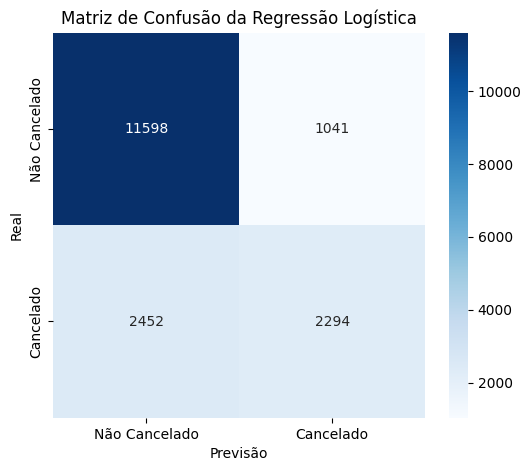

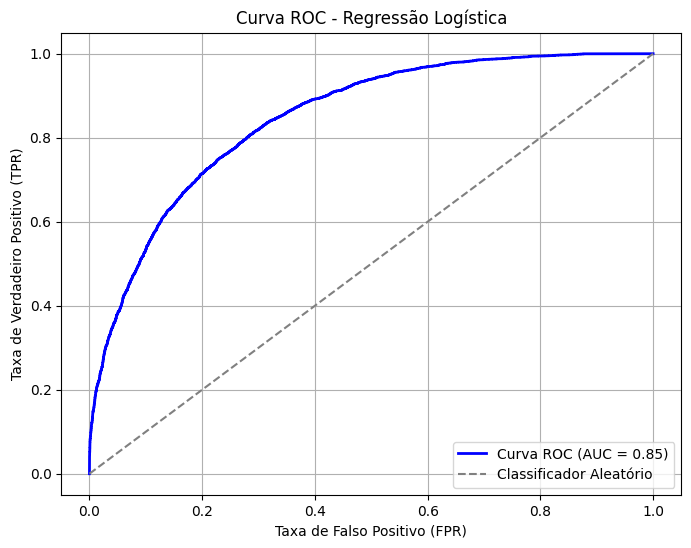

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy:.4f}")

# 2. Precisão
precision = precision_score(y_test, y_pred)
print(f"Precisão: {precision:.4f}")

# 3. Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

# 4. F1-Score
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

# 5. Matriz de Confusão
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão:")
display(pd.DataFrame(conf_matrix, index=['Real Negativo (0)', 'Real Positivo (1)'], columns=['Previsto Negativo (0)', 'Previsto Positivo (1)']))

# Plotar a Matriz de Confusão
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Cancelado', 'Cancelado'],
            yticklabels=['Não Cancelado', 'Cancelado'])
plt.title('Matriz de Confusão da Regressão Logística')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

# 6. Curva ROC e AUC
# y_pred_proba foi calculada anteriormente como a probabilidade da classe positiva (1)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Classificador Aleatório')
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Curva ROC - Regressão Logística')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

O modelo de Regressão Logística foi avaliado com sucesso, e os resultados nos dão uma boa visão do seu desempenho. Vamos analisar as métricas:

- **Acurácia: 79.91%** - Isso significa que o modelo acertou quase 80% das previsões no total.
- **Precisão: 68.79%** - Dos casos que o modelo previu como cancelados, cerca de 68.79% realmente foram cancelados. Isso é importante para evitar alertar erroneamente sobre cancelamentos.
- **Recall: 48.34%** - O modelo conseguiu identificar corretamente 48.34% de todos os cancelamentos reais. Isso significa que ele ainda está perdendo uma parte significativa dos cancelamentos.
- **F1-Score: 56.78%** - O F1-Score é a média harmônica de precisão e recall. Ele reflete um equilíbrio entre as duas métricas, indicando que há espaço para melhorias, especialmente no recall.

**Matriz de Confusão:**

<center>

| | Previsto Não Cancelado (0) | Previsto Cancelado (1) |
| :--- | :---: | :---: |
| **Real Não Cancelado (0)** | 11598 | 1041 |
| **Real Cancelado (1)** | 2452 | 2294 |

</center>


- **Verdadeiros Negativos (11598)**: O modelo previu corretamente que 11598 reservas não seriam canceladas.
- **Falsos Positivos (1041)**: O modelo previu que 1041 reservas seriam canceladas, mas elas não foram (um erro de tipo I).
- -**Falsos Negativos (2452)**: O modelo previu que 2452 reservas não seriam canceladas, mas elas foram (um erro de tipo II). Este é o principal motivo do recall mais baixo.
- **Verdadeiros Positivos (2294)**: O modelo previu corretamente que 2294 reservas seriam canceladas.

**Curva ROC e AUC**:

O **AUC (Area Under the Curve) de 0.85** é um bom indicador. Um valor de 0.5 representa um classificador aleatório e 1.0 um classificador perfeito. Um AUC de 0.85 sugere que o modelo tem uma boa capacidade de distinguir entre as classes 'cancelado' e 'não cancelado'.

**Conclusão:**

O modelo de Regressão Logística apresenta um desempenho razoável, com boa acurácia geral e capacidade de discriminação (AUC). No entanto, o **recall de 48.34%** indica que ele ainda tem dificuldade em identificar uma parcela significativa dos cancelamentos reais. Dependendo do custo dos falsos negativos (perder um cancelamento real), pode ser necessário otimizar o modelo para melhorar essa métrica.

Para as próximas etapas, poderíamos:

1. Ajustar o limiar de decisão do classificador para equilibrar precisão e recall, se uma métrica for mais crítica que a outra.
2. Experimentar outros modelos de classificação, como Random Forest, Gradient Boosting (XGBoost, LightGBM) ou SVMs, que podem ter maior poder preditivo para este problema.
3. Realizar ajuste de hiperparâmetros no modelo de Regressão Logística ou em outros modelos para otimizar ainda mais o desempenho.

Antes de testar outros modelos, ajustar o limiar de decisão pode ser muito eficaz para encontrar um melhor equilíbrio entre precisão e recall. Vou gerar uma visualização da Curva Precision-Recall para ajudar a identificar um limiar ideal.

### Ajuste do Limiar de Decisão (Decision Threshold)

O limiar de decisão padrão para a maioria dos classificadores é 0.5. No entanto, dependendo do problema e do custo associado a falsos positivos e falsos negativos, podemos ajustar esse limiar para otimizar métricas específicas (como precisão ou recall).

Vou plotar a Curva Precision-Recall e a Curva ROC novamente, mas desta vez, adicionando a opção de visualização do limiar, para que possamos analisar a troca entre Precisão, Recall e Falso Positivo em diferentes pontos de corte.

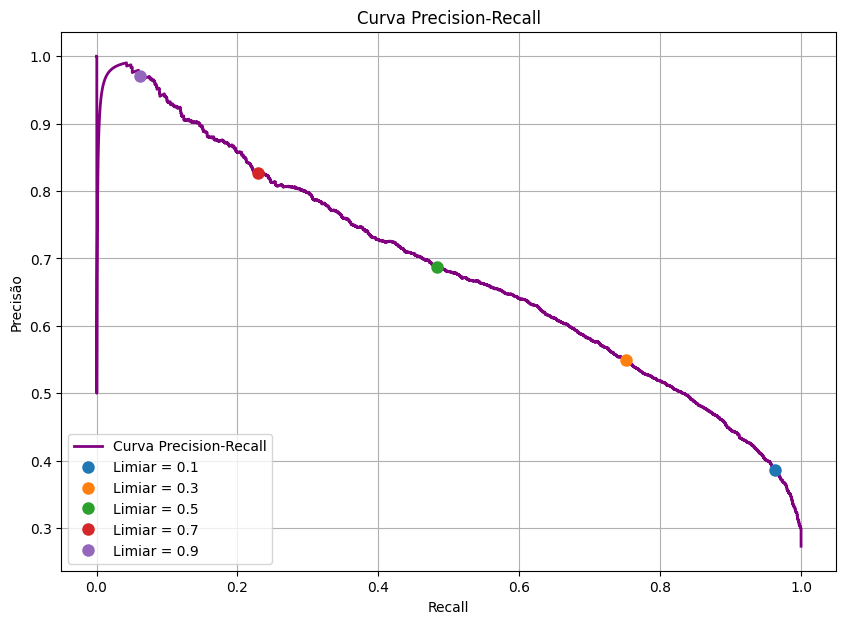

A curva Precision-Recall foi plotada. Analise a relação entre precisão e recall em diferentes limiares. Um limiar de 0.5 é o padrão.


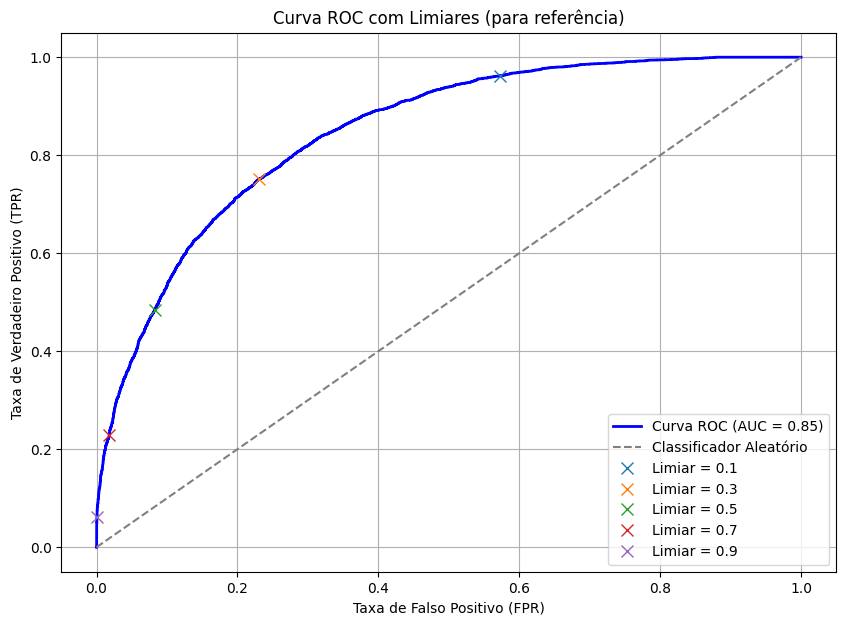

A curva ROC também foi plotada com os limiares para referência.


In [26]:
from sklearn.metrics import precision_recall_curve

# Gerar a curva Precision-Recall
precision_points, recall_points, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)

# Plotar a Curva Precision-Recall
plt.figure(figsize=(10, 7))
plt.plot(recall_points, precision_points, color='purple', lw=2, label='Curva Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall')
plt.grid(True)

# Plotar alguns pontos de limiar para referência
# Podemos escolher alguns limiares de interesse, por exemplo, onde a precisão e o recall se cruzam ou onde há uma mudança significativa
thresholds_to_show = [0.1, 0.3, 0.5, 0.7, 0.9]
for t in thresholds_to_show:
    # Encontrar o índice do limiar mais próximo
    idx = (abs(thresholds_pr - t)).argmin()
    plt.plot(recall_points[idx], precision_points[idx], 'o', markersize=8, label=f'Limiar = {t:.1f}')

plt.legend(loc='lower left')
plt.show()

print("A curva Precision-Recall foi plotada. Analise a relação entre precisão e recall em diferentes limiares. Um limiar de 0.5 é o padrão.")

# Para análise da Curva ROC com limiares (se necessário para entender a relação FPR/TPR)
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Classificador Aleatório')
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Curva ROC com Limiares (para referência)')
plt.grid(True)

# Adicionar alguns pontos de limiar na Curva ROC
for t in thresholds_to_show:
    idx = (abs(thresholds_roc - t)).argmin()
    plt.plot(fpr[idx], tpr[idx], 'x', markersize=8, label=f'Limiar = {t:.1f}')
plt.legend(loc='lower right')
plt.show()

print("A curva ROC também foi plotada com os limiares para referência.")

### Reavaliação do Modelo com Novo Limiar de Decisão (0.3)

Agora, aplicaremos o limiar de decisão escolhido (`0.3`) para recalcular as previsões (`y_pred_new_threshold`) e, em seguida, reavaliar as métricas de desempenho do modelo.

--- Avaliação do Modelo com Limiar de Decisão = 0.3 ---
Nova Acurácia: 0.7642
Nova Precisão: 0.5498
Novo Recall: 0.7516
Novo F1-Score: 0.6350

Nova Matriz de Confusão:


,Previsto Negativo (0),Previsto Positivo (1)
Real Negativo (0),9718,2921
Real Positivo (1),1179,3567


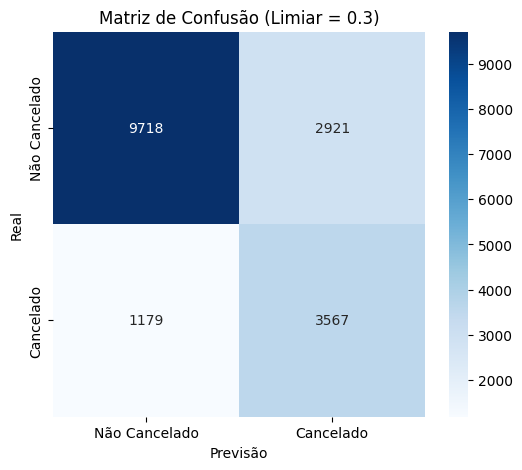

Com o limiar de 0.3, o modelo agora detecta mais cancelamentos (maior Recall), mas isso pode vir com um aumento de falsos positivos (menor Precisão).


In [27]:
import numpy as np

# Definir o novo limiar
new_threshold = 0.3

# Recalcular as previsões com o novo limiar
y_pred_new_threshold = (y_pred_proba >= new_threshold).astype(int)

print(f"--- Avaliação do Modelo com Limiar de Decisão = {new_threshold} ---")

# 1. Acurácia
accuracy_new = accuracy_score(y_test, y_pred_new_threshold)
print(f"Nova Acurácia: {accuracy_new:.4f}")

# 2. Precisão
precision_new = precision_score(y_test, y_pred_new_threshold)
print(f"Nova Precisão: {precision_new:.4f}")

# 3. Recall
recall_new = recall_score(y_test, y_pred_new_threshold)
print(f"Novo Recall: {recall_new:.4f}")

# 4. F1-Score
f1_new = f1_score(y_test, y_pred_new_threshold)
print(f"Novo F1-Score: {f1_new:.4f}")

# 5. Matriz de Confusão
conf_matrix_new = confusion_matrix(y_test, y_pred_new_threshold)
print("\nNova Matriz de Confusão:")
display(pd.DataFrame(conf_matrix_new, index=['Real Negativo (0)', 'Real Positivo (1)'], columns=['Previsto Negativo (0)', 'Previsto Positivo (1)']))

# Plotar a Nova Matriz de Confusão
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_new, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Cancelado', 'Cancelado'],
            yticklabels=['Não Cancelado', 'Cancelado'])
plt.title(f'Matriz de Confusão (Limiar = {new_threshold})')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

print(f"Com o limiar de {new_threshold}, o modelo agora detecta mais cancelamentos (maior Recall), mas isso pode vir com um aumento de falsos positivos (menor Precisão).")

Vamos reavaliar o modelo de Regressão Logística com um novo limiar de decisão de **0.3**. Isso deve priorizar a identificação de mais cancelamentos (aumentar o recall), potencialmente ao custo de mais falsos positivos (diminuir a precisão).

Excelente! O modelo foi reavaliado com o limiar de decisão de **0.3**. Como esperado, houve uma mudança nas métricas:

**Métricas com Limiar 0.3 (vs. Limiar 0.5)**:

- **Nova Acurácia: 76.42%** (antes 79.91% - leve queda)
- **Nova Precisão: 54.98%** (antes 68.79% - queda significativa)
- **Novo Recall: 75.16%** (antes 48.34% - aumento significativo)
- **Novo F1-Score: 63.50%** (antes 56.78% - aumento)

**Nova Matriz de Confusão (Limiar 0.3)**:

<center>

| | Previsto Não Cancelado (0) | Previsto Cancelado (1) |
| :--- | :---: | :---: |
| **Real Não Cancelado (0)** | 9718 | 2921 |
| **Real Cancelado (1)** | 1179 | 3567 |

</center>


**Análise**:

- **Recall (75.16%)**: Houve um aumento substancial no recall. Isso significa que o modelo agora está identificando muito mais dos cancelamentos reais (3567 verdadeiros positivos contra 2294 anteriormente). Se o objetivo é minimizar os falsos negativos (perder um cancelamento real), este limiar é superior.
- **Precisão (54.98%)**: A precisão diminuiu consideravelmente. Agora, dos casos que o modelo prevê como cancelados, apenas 54.98% realmente se concretizam. Isso significa que há mais falsos positivos (2921 contra 1041 anteriormente), ou seja, o modelo está marcando muitas reservas como cancelamento que, na verdade, não serão. Se o custo de um falso positivo for alto (ex: gastar recursos tentando reter clientes que não iam cancelar), esta precisão pode ser um problema.
- **F1-Score (63.50%)**: O F1-Score aumentou, o que indica um melhor equilíbrio geral entre precisão e recall para este limiar.
Esta mudança demonstra claramente o trade-off entre precisão e recall. Ao reduzir o limiar para 0.3, você tornou o modelo mais sensível a cancelamentos, mas também mais propenso a cometer erros ao prever um cancelamento onde não haverá.

Esta mudança demonstra claramente o trade-off entre precisão e recall. Ao reduzir o limiar para 0.3, você tornou o modelo mais sensível a cancelamentos, mas também mais propenso a cometer erros ao prever um cancelamento onde não haverá.

### Reavaliação do Modelo com Novo Limiar de Decisão (0.4)

Vamos aplicar o limiar de decisão de `0.4` para recalcular as previsões e analisar as métricas de desempenho novamente.

--- Avaliação do Modelo com Limiar de Decisão = 0.4 ---
Nova Acurácia: 0.7972
Nova Precisão: 0.6305
Novo Recall: 0.6216
Novo F1-Score: 0.6260

Nova Matriz de Confusão:


,Previsto Negativo (0),Previsto Positivo (1)
Real Negativo (0),10910,1729
Real Positivo (1),1796,2950


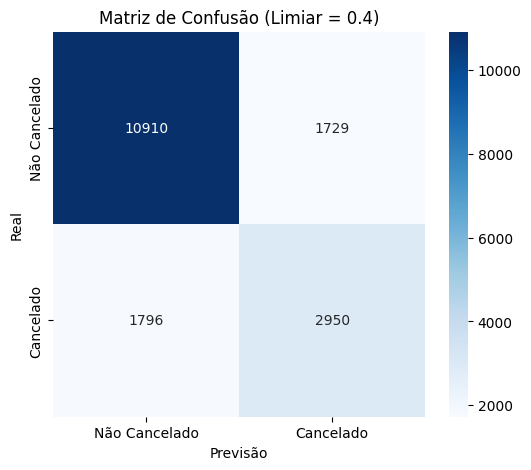

Com o limiar de 0.4, observe as mudanças no Recall e Precisão.


In [28]:
import numpy as np

# Definir o novo limiar
new_threshold = 0.4

# Recalcular as previsões com o novo limiar
y_pred_new_threshold = (y_pred_proba >= new_threshold).astype(int)

print(f"--- Avaliação do Modelo com Limiar de Decisão = {new_threshold} ---")

# 1. Acurácia
accuracy_new = accuracy_score(y_test, y_pred_new_threshold)
print(f"Nova Acurácia: {accuracy_new:.4f}")

# 2. Precisão
precision_new = precision_score(y_test, y_pred_new_threshold)
print(f"Nova Precisão: {precision_new:.4f}")

# 3. Recall
recall_new = recall_score(y_test, y_pred_new_threshold)
print(f"Novo Recall: {recall_new:.4f}")

# 4. F1-Score
f1_new = f1_score(y_test, y_pred_new_threshold)
print(f"Novo F1-Score: {f1_new:.4f}")

# 5. Matriz de Confusão
conf_matrix_new = confusion_matrix(y_test, y_pred_new_threshold)
print("\nNova Matriz de Confusão:")
display(pd.DataFrame(conf_matrix_new, index=['Real Negativo (0)', 'Real Positivo (1)'], columns=['Previsto Negativo (0)', 'Previsto Positivo (1)']))

# Plotar a Nova Matriz de Confusão
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_new, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Cancelado', 'Cancelado'],
            yticklabels=['Não Cancelado', 'Cancelado'])
plt.title(f'Matriz de Confusão (Limiar = {new_threshold})')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

print(f"Com o limiar de {new_threshold}, observe as mudanças no Recall e Precisão.")

O modelo foi reavaliado com um limiar de decisão de **0.4**, e aqui estão as métricas resultantes, comparadas com os limiares anteriores (**0.5** padrão e **0.3** ajustado):

**Métricas com Limiar 0.4**:

- **Acurácia:** 79.72%
- **Precisão**: 63.05%
- **Recall**: 62.16%
- **F1-Score**: 62.60%

**Nova Matriz de Confusão (Limiar 0.4)**:

<center>

| | Previsto Não Cancelado (0) | Previsto Cancelado (1) |
| :--- | :---: | :---: |
| **Real Não Cancelado (0)** | 10910 | 1729 |
| **Real Cancelado (1)** | 1796 | 2950 |

</center>


**Análise e Comparação:**

- **Acurácia**: Permanece alta em 79.72%, muito próxima do limiar padrão de 0.5 (79.91%) e um pouco maior que a do limiar de 0.3 (76.42%).
- **Precisão**: Melhorou significativamente em relação ao limiar de 0.3 (54.98%), subindo para 63.05%. No entanto, ainda é um pouco menor que a precisão do limiar de 0.5 (68.79%). Isso significa que, com este limiar, o modelo comete menos falsos positivos do que com o limiar de 0.3, mas ainda mais do que com 0.5.
- **Recall:** Também melhorou em relação ao limiar de 0.5 (48.34%), atingindo 62.16%. No entanto, é menor que o recall alcançado com o limiar de 0.3 (75.16%). Isso indica que o modelo identifica uma boa parte dos cancelamentos reais, mas não tantos quanto com o limiar mais baixo.
- **F1-Score**: Apresenta um valor de 62.60%, que é intermediário entre o F1-Score do limiar de 0.5 (56.78%) e o de 0.3 (63.50%).

**Conclusão sobre o Limiar 0.4:**

O limiar de 0.4 parece oferecer um bom equilíbrio entre precisão e recall para este modelo, sendo um ponto intermediário em relação aos outros dois limiares testados. Ele consegue um recall razoável para identificar cancelamentos, sem sacrificar a precisão de forma tão acentuada quanto o limiar de 0.3. Dependendo do custo relativo de falsos positivos versus falsos negativos, este pode ser um limiar adequado.

### Treinamento e Avaliação do Modelo Random Forest

Agora que exploramos o modelo de Regressão Logística e seus limiares de decisão, vamos experimentar um modelo mais robusto, o **Random Forest Classifier**. Árvores de decisão e seus conjuntos (como Random Forest) são poderosos em capturar relações não lineares e interações entre variáveis, o que pode levar a um melhor desempenho.

Vamos treinar um modelo Random Forest com os dados escalados e avaliá-lo usando as mesmas métricas (Acurácia, Precisão, Recall, F1-Score e Matriz de Confusão).

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar o modelo Random Forest
# Usaremos um número razoável de estimadores (n_estimators) e um random_state para reprodutibilidade
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 para usar todos os cores disponíveis

# Treinar o modelo com os dados de treinamento escalados
rf_model.fit(X_train_scaled, y_train)

print("Modelo Random Forest treinado com sucesso!")

# Fazer previsões no conjunto de teste escalado
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1] # Probabilidades da classe positiva (cancelado)

print("Previsões realizadas no conjunto de teste com Random Forest.")

Modelo Random Forest treinado com sucesso!
Previsões realizadas no conjunto de teste com Random Forest.


### Avaliação do Modelo Random Forest (Limiar Padrão 0.5)

Vamos tentar um classificador Random Forest. Este modelo geralmente oferece melhor desempenho do que a regressão logística devido à sua capacidade de capturar relacionamentos e interações não lineares entre recursos. Treinarei e avaliarei um modelo Random Forest usando as mesmas métricas de antes.

Acurácia Random Forest: 0.8448
Precisão Random Forest: 0.7751
Recall Random Forest: 0.6079
F1-Score Random Forest: 0.6814

Matriz de Confusão Random Forest:


,Previsto Negativo (0),Previsto Positivo (1)
Real Negativo (0),11802,837
Real Positivo (1),1861,2885


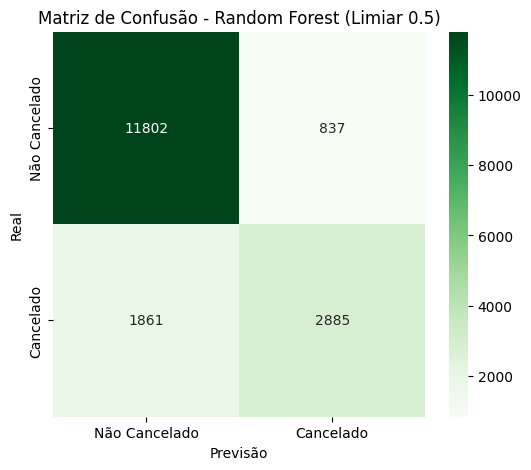

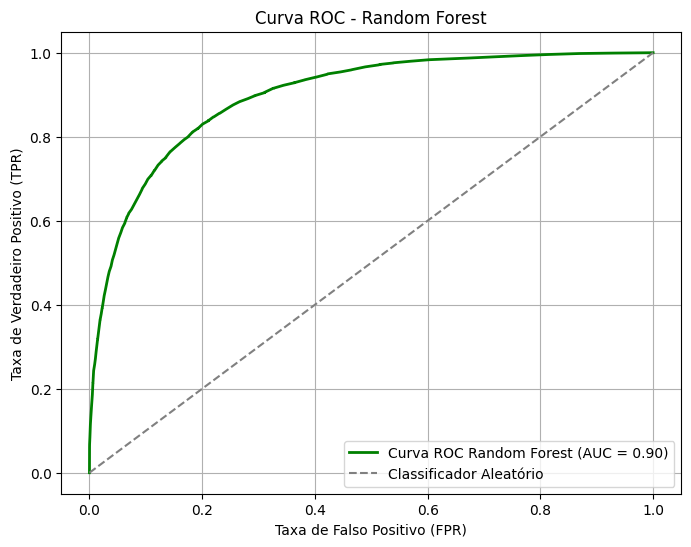

In [30]:
# 1. Acurácia
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Acurácia Random Forest: {accuracy_rf:.4f}")

# 2. Precisão
precision_rf = precision_score(y_test, y_pred_rf)
print(f"Precisão Random Forest: {precision_rf:.4f}")

# 3. Recall
recall_rf = recall_score(y_test, y_pred_rf)
print(f"Recall Random Forest: {recall_rf:.4f}")

# 4. F1-Score
f1_rf = f1_score(y_test, y_pred_rf)
print(f"F1-Score Random Forest: {f1_rf:.4f}")

# 5. Matriz de Confusão
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nMatriz de Confusão Random Forest:")
display(pd.DataFrame(conf_matrix_rf, index=['Real Negativo (0)', 'Real Positivo (1)'], columns=['Previsto Negativo (0)', 'Previsto Positivo (1)']))

# Plotar a Matriz de Confusão
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Não Cancelado', 'Cancelado'],
            yticklabels=['Não Cancelado', 'Cancelado'])
plt.title('Matriz de Confusão - Random Forest (Limiar 0.5)')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

# 6. Curva ROC e AUC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Curva ROC Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Classificador Aleatório')
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Curva ROC - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

O modelo Random Forest foi treinado e avaliado com sucesso. Vamos analisar os resultados e compará-los com o modelo de Regressão Logística:

**Métricas do Random Forest (Limiar Padrão 0.5):**

- **Acurácia**: 84.48%
- **Precisão**: 77.51%
- **Recall**: 60.79%
- **F1-Score**: 68.14%
- **AUC**: 0.90 (da Curva ROC plotada)

**Matriz de Confusão do Random Forest**:

<center>

| | Previsto Não Cancelado (0) | Previsto Cancelado (1) |
| :--- | :---: | :---: |
| **Real Não Cancelado (0)** | 11802 | 837 |
| **Real Cancelado (1)** | 1861 | 2885 |

</center>

<center>

### Comparação com a Regressão Logística (Limiar Padrão 0.5)


| Métrica | Regressão Logística (0.5) | Random Forest (0.5) |
| :--- | :---: | :---: |
| **Acurácia** | 79.91% | 84.48% |
| **Precisão** | 68.79% | 77.51% |
| **Recall** | 48.34% | 60.79% |
| **F1-Score** | 56.78% | 68.14% |
| **AUC** | 0.85 | 0.90 |

</center>

**Análise:**

Como podemos ver, o modelo **Random Forest superou significativamente a Regressão Logística** em todas as métricas, utilizando o limiar padrão de 0.5:

- **Acurácia**: O Random Forest teve uma acurácia notavelmente maior (84.48% vs 79.91%), indicando que ele faz mais previsões corretas no geral.
- **Precisão**: A precisão do Random Forest é de 77.51%, o que é uma melhoria substancial em relação aos 68.79% da Regressão Logística. Isso significa que, quando o Random Forest prevê um cancelamento, ele está correto em uma porcentagem maior dos casos, reduzindo os falsos positivos.
- **Recall**: O Recall também mostrou uma melhora expressiva, passando de 48.34% para 60.79%. Isso significa que o Random Forest é capaz de identificar uma parcela maior dos cancelamentos reais, diminuindo os falsos negativos.
- **F1-Score**: O F1-Score, que é uma métrica de equilíbrio, aumentou de 56.78% para 68.14%, reforçando a melhoria geral no desempenho.
- **AUC**: O AUC de 0.90 para o Random Forest (contra 0.85 da Regressão Logística) indica que ele tem uma capacidade discriminatória superior para distinguir entre reservas canceladas e não canceladas.

**Conclusão:**

O **Random Forest é um modelo muito mais eficaz para este problema**, entregando um desempenho superior em todas as métricas avaliadas. Ele consegue um melhor equilíbrio entre identificar corretamente os cancelamentos (recall) e evitar prever cancelamentos erroneamente (precisão). Isso se deve provavelmente à sua capacidade de lidar com relações não lineares e interações complexas entre as features.

Com o Random Forest, podemos ter mais confiança nas previsões e usar essas informações para tomar decisões mais eficazes, como implementar estratégias de retenção para clientes com alta probabilidade de cancelar.

Chegamos ao fim do processo de modelagem de predição de cancelamento de reservas. Realizamos uma análise completa, desde a exploração inicial dos dados até o treinamento e avaliação de modelos de Machine Learning. Este processo ainda pode ser aprimorado com o uso de outros modelos e ajustes.